========================================================================================


Nama : Ananda Karnia Amalya

BAtch: Hck -027


link dataset:
https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

Penyakit jantung merupakan salah satu penyebab utama kematian di dunia, termasuk di Indonesia. Berdasarkan data dari Kementerian Kesehatan Republik Indonesia (2023), penyakit jantung iskemik dan stroke menjadi penyumbang tertinggi dalam angka kematian nasional.

Deteksi dini terhadap risiko penyakit jantung sangat penting guna mencegah komplikasi dan meningkatkan efektivitas pengobatan. Namun, proses diagnosis tradisional biasanya membutuhkan waktu, biaya tinggi, dan akses ke fasilitas kesehatan yang memadai. Dalam konteks ini, teknologi machine learning, khususnya pendekatan klasifikasi, dapat dimanfaatkan untuk membantu proses prediksi risiko secara otomatis berdasarkan data kesehatan pasien.

Dengan mencari hubungan antara gaya hidup dan kodisi medis pada variable yang diperlukan, sehingga dapat menentukan pakah seseorang beresiko terdhadap penyakit jantung atau tidak

jurnal pendukung:
https://en.antaranews.com/news/294543/cardiovascular-diseases-responsible-for-most-deaths-health-ministry?utm_source=chatgpt.com

======================================================================================

# I. Import Library

In [914]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import numpy as np
import seaborn as sns
import joblib


from sklearn.preprocessing import LabelEncoder
from scipy.stats import kendalltau
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV

# SVM
from sklearn.svm import SVC

# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score, recall_score

# II. Data Loading

In [819]:
data = pd.read_csv('heart_2020_cleaned.csv')
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


Dari data ini dapat diliat bahwa dataset ini terdiri dari 319.795 baris dan 18 kolom. Data ini merupakan data kesehatan yang berkaitan dengan penyakit maupun kebiasaan yang mendukung atau ternyata berkontribusi dalam peningkatan penyakit jantung.

In [820]:
df = data.copy()

# Data Prapretion

In [821]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

Pada method info() ini dapat diliat bahwa mayoritas dari tipe datanya adalah object. 

## Check Missing Value

In [822]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

Data kali ini bersih atau tidak terdapat missing value pada semua kolom dataset ini.

## Check Column Name

In [823]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

Pengecekan apakah terdapat white space pada nama semua kolom dataset gunanya untuk mempermudah dalam penulisan ketika peroses analis. Ternyata tidak terdapat white space pada semua nama kolom.

## Check Statistik Deskriptif

In [824]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,319795,2,No,292422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,319795.0,NaN,NaN,NaN,28.325399,6.3561,12.02,24.03,27.34,31.42,94.85
Smoking,319795,2,No,187887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,319795,2,No,298018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,319795,2,No,307726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,319795.0,NaN,NaN,NaN,3.37171,7.95085,0.0,0.0,0.0,2.0,30.0
MentalHealth,319795.0,NaN,NaN,NaN,3.898366,7.955235,0.0,0.0,0.0,3.0,30.0
DiffWalking,319795,2,No,275385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,319795,2,Female,167805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,319795,13,65-69,34151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Describe untuk menampilkan ringkasan statistik lengkap dari seluruh kolom dalam DataFrame. Terjadinya NaN pada kolom numerik disebabkan unique, top dan freq tidak relevan dengan data numerik. Sedangkan untuk data kategorik terjadi NaN karena mean, sdt, min dan lain-lain tidak relevan karena bukan data numerik.

## Pengecekan Column Kategorik

Pengecekan kolom ini digunakan untuk mengetahui dan mengelompokkan kolom yang categorik.

In [825]:
# Mengecek semua kolom numerik

cat_list = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Variables:", cat_list)

Categorical Variables: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [826]:
df[cat_list].nunique()

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

Pengecekan hanya unique value hanya ada di kolom kategorik untuk mengetahui apakah terdapat high cardinal atau tidak.

## Pengecekan Column Numerik

Pengecekan kolom ini digunakan untuk mengetahui dan mengelompokkan kolom yang numerik.

In [827]:
# Mengecek semua kolom numerik
num_list = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Kolom numerik: ', num_list)

Kolom numerik:  ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


## Check Duplicate

In [828]:
# Mengecek nilai duplikat yang ada
df.duplicated().sum()

18078

Terdapat cukup banyak duplikat pada dataset ini yaitu sebanyak 18078. Perlu ditinjau lebih jauh apa saja kolom yang terdapat duplikat. 

# EDA

## 1. Analisis jumlah orang dengan dan tanpa penyakit jantung

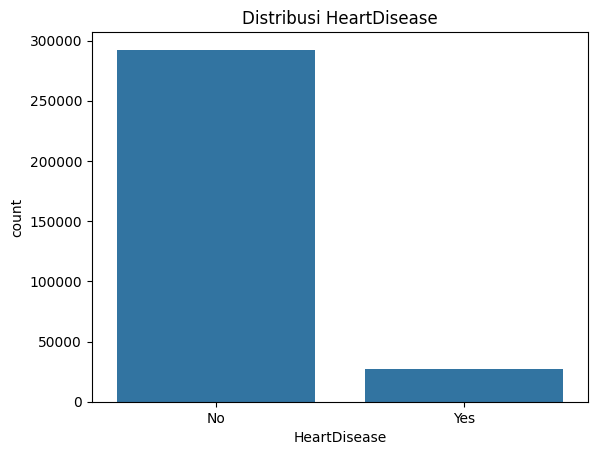

In [829]:

sns.countplot(x='HeartDisease', data=df)
plt.title('Distribusi HeartDisease')
plt.show()


Terdapat jauh lebih banyak yang tidak memiliki penyakit jantung pada data ini.

## 2. Mengetahui proporsi persepsi kesehatan secara umum (Excellent, Good, Fair, dll.).

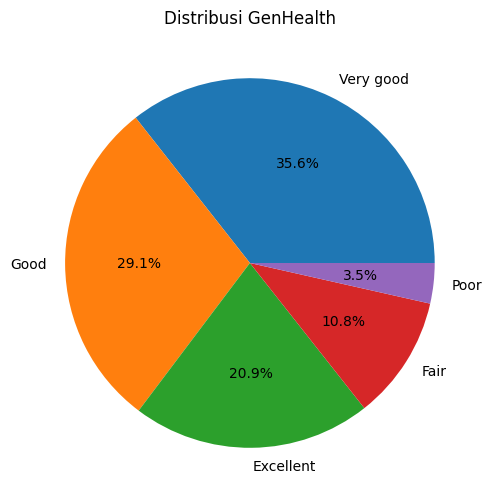

In [830]:
plt.figure(figsize=(6, 6))
df['GenHealth'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title("Distribusi GenHealth")
plt.show()

Dilakukan Pengecekan persepsi kesehatan menggunakan piechart agar mempermudah melihat persentase persepsi dari GenHealth itu sendiri.

## 3. Korelasi antar variabel numerik (BMI, PhysicalHealth, MentalHealth, SleepTime).

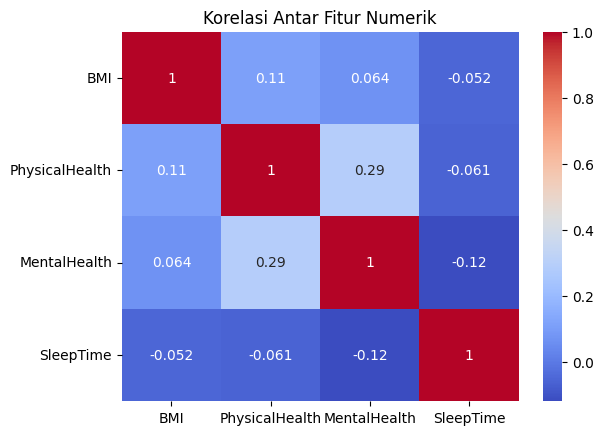

In [831]:
corr = df[num_list].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

Digunakan matriks hanya untuk numerik, karena kategorik tidak dapat di gunakan matrix correlation. 

- BMI paling berkorelasi dengan PhysicalHealth namun sangat sedikit korelasinya. 
- MentalHealth paling berkorelasi dengan PhysicalHealth namun sangat sedikit korelasinya.
- Sleeptime yang paling berkorelasi adalah MentalHealth namun sangat sedikit korelasinya.

## 4. Analisis Fitur Kategorikal terhadap HeartDisease

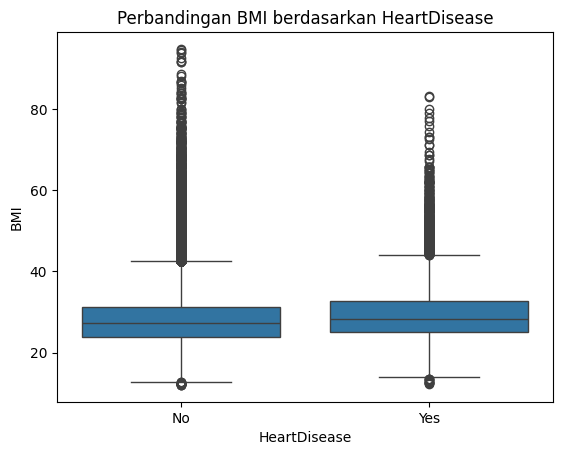

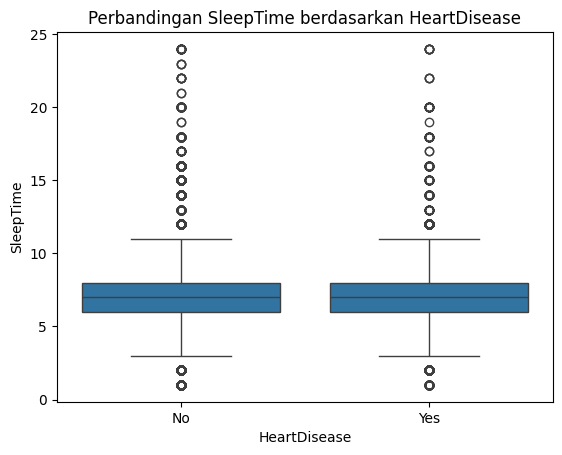

In [832]:
sns.boxplot(x='HeartDisease', y='BMI', data=df)
plt.title('Perbandingan BMI berdasarkan HeartDisease')
plt.show()

sns.boxplot(x='HeartDisease', y='SleepTime', data=df)
plt.title('Perbandingan SleepTime berdasarkan HeartDisease')
plt.show()

BMI yang lebih tinggi cenderung berhubungan dengan adanya penyakit jantung, meskipun perbedaannya tidak terlalu besar secara visual.

Durasi tidur tampaknya tidak menjadi pembeda utama antara kelompok yang memiliki penyakit jantung dan yang tidak.

## 5.  Analisis AgeCategory dan GenHealth terhadap HeartDisease

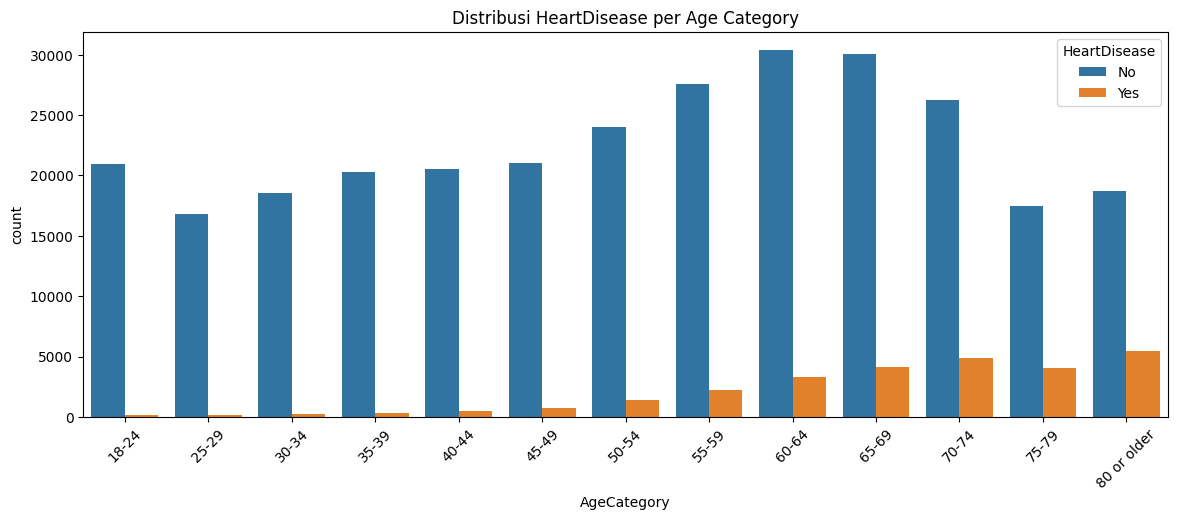

In [834]:
plt.figure(figsize=(14, 5))

# Distribusi HeartDisease per AgeCategory
sns.countplot(x='AgeCategory', hue='HeartDisease', data=df, order=sorted(df['AgeCategory'].unique()))
plt.title('Distribusi HeartDisease per Age Category')
plt.xticks(rotation=45)
plt.show()


Terlihat bahwa semakin tua umur dari seseorang semakin besar juga potensi dia terkena penyakit jantung

Mayoritas orang tidur dalam durasi normal (6-9 jam), dan sebagian besar dari mereka tidak memiliki penyakit jantung.Pada semua kategori tidur (pendek, normal, panjang), proporsi penderita penyakit jantung lebih rendah dibandingkan yang tidak menderita.Namun, kategori tidur pendek (<6 jam) dan panjang (>9 jam) memiliki proporsi penderita penyakit jantung yang relatif lebih tinggi dibandingkan kategori tidur normal. Tidur terlalu sedikit atau terlalu lama cenderung berkaitan dengan peningkatan risiko penyakit jantung. Pola ini menunjukkan bahwa durasi tidur yang optimal (6–9 jam) mungkin berperan dalam menjaga kesehatan jantung.

Kesimpulan: Tidur dengan durasi normal (6–9 jam) berhubungan dengan risiko penyakit jantung yang lebih rendah dibandingkan tidur terlalu singkat atau terlalu lama.

## 6. Analisis hubungan merokok berdasarkan HeartDisease

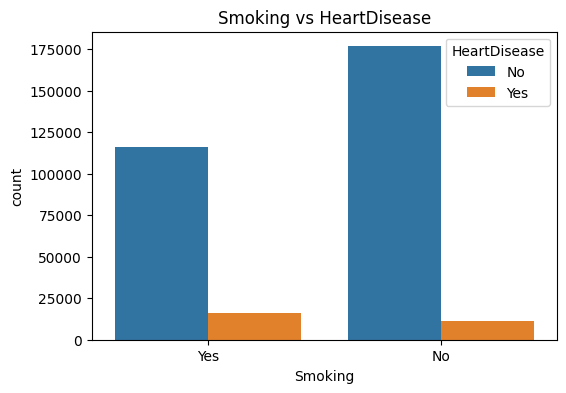

In [837]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Smoking', hue='HeartDisease')
plt.title("Smoking vs HeartDisease")
plt.show()


Jumlah perokok yang tidak menderita penyakit jantung lebih rendah dibandingkan non-perokok yang tidak menderita penyakit jantung.Namun, proporsi penderita penyakit jantung di antara perokok lebih tinggi dibandingkan dengan non-perokok.ni terlihat dari tingginya batang oranye (HeartDisease = Yes) pada kelompok perokok dibandingkan non-perokok.Artinya, merokok berkaitan dengan peningkatan risiko terkena penyakit jantung.

Kesimpulan: Merokok tampaknya menjadi faktor risiko signifikan terhadap penyakit jantung. Meskipun jumlah perokok mungkin lebih sedikit daripada non-perokok, proporsi penderita penyakit jantung di antara perokok lebih tinggi.

## 7. Distribusi SleepTime yang dibedakan berdasarkan status HeartDisease

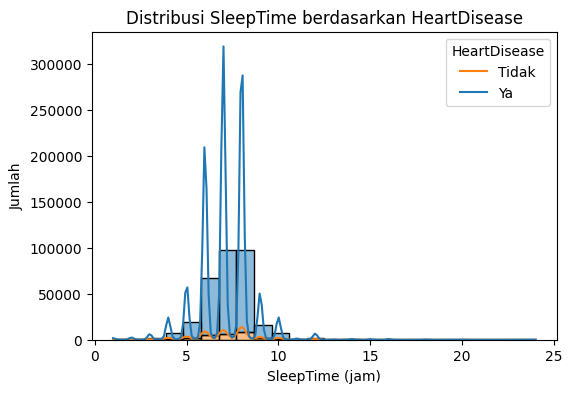

In [908]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='SleepTime', bins=24, kde=True, hue='HeartDisease', multiple='stack')
plt.title("Distribusi SleepTime berdasarkan HeartDisease")
plt.xlabel("SleepTime (jam)")
plt.ylabel("Jumlah")
plt.legend(title='HeartDisease', labels=['Tidak', 'Ya'])  # Opsional: label dalam bahasa Indonesia
plt.show()


Mayoritas orang tidur antara 5 hingga 9 jam, baik yang memiliki penyakit jantung maupun yang tidak.Distribusi orang tanpa penyakit jantung (label "Tidak") jauh lebih tinggi dan lebih terkonsentrasi pada durasi tidur normal (sekitar 7–8 jam). Distribusi orang dengan penyakit jantung (label "Ya") cenderung lebih datar dan tersebar, tetapi juga banyak yang tidur di kisaran 6–8 jam.

Kesimpulan Umum:
Tidur dengan durasi 6–8 jam tampaknya merupakan pola tidur yang paling umum, terutama pada orang tanpa penyakit jantung. Sementara itu, penderita penyakit jantung memiliki pola tidur yang lebih menyebar, dengan indikasi jumlah yang lebih tinggi pada waktu tidur yang kurang dari ideal. Hal ini mengindikasikan bahwa durasi tidur yang tidak optimal bisa berhubungan dengan risiko penyakit jantung.

# Feature Engineering

## Sampling Data

Hal ini dilakukan karena data asli yang terlalu besar yaitu 300.000 baris. Hal itu dapat berimpact pada lamanya modeling karena model harus bekerja keras untuk mengolah data yang besar. selain itu juga dikarenakan keterbatasan waktu sehingga sampling ini merupakan pilihan terbaik untuk pengolahan data.

In [ ]:
df_sampled = df.sample(frac=0.03, random_state=42)  # 3% data, digunkana random state agar datanya tidak berubah ubah
df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9594 entries, 271884 to 208497
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      9594 non-null   object 
 1   BMI               9594 non-null   float64
 2   Smoking           9594 non-null   object 
 3   AlcoholDrinking   9594 non-null   object 
 4   Stroke            9594 non-null   object 
 5   PhysicalHealth    9594 non-null   float64
 6   MentalHealth      9594 non-null   float64
 7   DiffWalking       9594 non-null   object 
 8   Sex               9594 non-null   object 
 9   AgeCategory       9594 non-null   object 
 10  Race              9594 non-null   object 
 11  Diabetic          9594 non-null   object 
 12  PhysicalActivity  9594 non-null   object 
 13  GenHealth         9594 non-null   object 
 14  SleepTime         9594 non-null   float64
 15  Asthma            9594 non-null   object 
 16  KidneyDisease     9594 non-null   object

## a. Handling Cadinality 

In [843]:
df_sampled[cat_list].nunique()

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

Pengecekan cardinality hanya dilakukan untuk kolom kategorik. disini dapat terlihat yang paling banyak adalah AgeCategory namun saya sudah melakukan pengelompokkan dan membuat kolom baru.

## b. Handling Duplicate

In [844]:
df_sampled.duplicated().sum()

28

In [845]:
duplikat_per_kolom = df_sampled.apply(lambda col: col.duplicated().sum())

print("Jumlah duplikat per kolom:")
print(duplikat_per_kolom)

Jumlah duplikat per kolom:
HeartDisease        9592
BMI                 8142
Smoking             9592
AlcoholDrinking     9592
Stroke              9592
PhysicalHealth      9563
MentalHealth        9564
DiffWalking         9592
Sex                 9592
AgeCategory         9581
Race                9588
Diabetic            9590
PhysicalActivity    9592
GenHealth           9589
SleepTime           9575
Asthma              9592
KidneyDisease       9592
SkinCancer          9592
SleepCategory       9591
dtype: int64


In [846]:
# Kolom yang mau dicek kombinasinya (bisa semua atau subset kolom)
kolom_cek = ['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
             'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
             'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
             'Asthma', 'KidneyDisease', 'SkinCancer']

# Hitung kombinasi data dan jumlah kemunculannya
kombinasi = df_sampled.groupby(kolom_cek).size().reset_index(name='jumlah_kemunculan')

# Ambil hanya yang muncul lebih dari 1 (duplikat)
kombinasi_duplikat = kombinasi[kombinasi['jumlah_kemunculan'] > 1]

# Tampilkan
kombinasi_duplikat

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,jumlah_kemunculan
359,No,19.79,Yes,No,No,0.0,0.0,No,Male,18-24,White,No,Yes,Excellent,7.0,No,No,No,2
1362,No,22.46,Yes,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Very good,8.0,Yes,No,No,2
1505,No,22.81,No,No,No,0.0,0.0,No,Male,50-54,White,No,Yes,Excellent,7.0,No,No,No,2
1623,No,23.03,No,No,No,0.0,0.0,No,Female,18-24,White,No,Yes,Very good,7.0,No,No,No,2
1973,No,23.67,No,No,No,0.0,0.0,No,Male,60-64,White,No,Yes,Excellent,8.0,No,No,No,2
2157,No,24.03,No,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Excellent,8.0,No,No,No,2
2459,No,24.41,No,No,No,0.0,0.0,No,Male,18-24,White,No,Yes,Very good,6.0,No,No,No,2
2472,No,24.41,No,No,No,0.0,0.0,No,Male,45-49,White,No,Yes,Very good,7.0,No,No,No,2
2476,No,24.41,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Excellent,7.0,No,No,No,2
2554,No,24.53,No,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Very good,7.0,No,No,No,2


In [847]:
df_sampled.loc[(df_sampled['BMI'] == 19.79	) & (df['PhysicalHealth'] == 0.0)]

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,SleepCategory
51438,No,19.79,Yes,No,No,0.0,3.0,No,Male,45-49,Other,No,Yes,Good,6.0,No,No,No,Normal (6-9h)
112949,No,19.79,Yes,No,No,0.0,0.0,No,Male,18-24,White,No,Yes,Excellent,7.0,No,No,No,Normal (6-9h)
308820,No,19.79,No,No,No,0.0,10.0,No,Female,60-64,White,No,Yes,Very good,6.0,Yes,No,No,Normal (6-9h)
52030,No,19.79,Yes,No,No,0.0,0.0,No,Male,18-24,White,No,Yes,Excellent,7.0,No,No,No,Normal (6-9h)


In [848]:
df_sampled = df_sampled.drop_duplicates()

In [849]:
df_sampled.duplicated().sum()

0

Setelah dilakukan pengecekan sekira apa penyebab dari duplicate itu terjadi apakah ada pola atau kesalahan input. Saya memutuskan untuk melakukan drop karena data hanya terduplicate. Duplicate juga dapat mengakibatkan redundansi.

## c. Split Train dan Test

Saya menetapkan HeartDisease menjadi target atau x dan sisanya menjadi feature.

In [850]:
# Split Feature dengan Target
x = df_sampled.drop(['HeartDisease'], axis=1)
y = df_sampled['HeartDisease'].map({'No' : 0, 'Yes' : 1})

In [851]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [852]:
# menimbulkan jumlah train dan test
print('Train size : ', x_train.shape)
print('Test size  : ', x_test.shape)

Train size :  (7652, 18)
Test size  :  (1914, 18)


Saya menggunakan perbandingan 80:20 dipilih karena memberikan kompromi ideal antara cukupnya data untuk pelatihan dan cukupnya data untuk evaluasi model secara akurat.

## d. Handling Missing Value

In [853]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
SleepCategory       0
dtype: int64

Tidak terdapat missing value sehingga tidak perlu di handling

## e. Handling Outlier

In [854]:
x_train[num_list].skew()

BMI               1.398528
PhysicalHealth    2.502472
MentalHealth      2.307999
SleepTime         0.908873
dtype: float64

### Visualisasi dari skew kolom numerikal

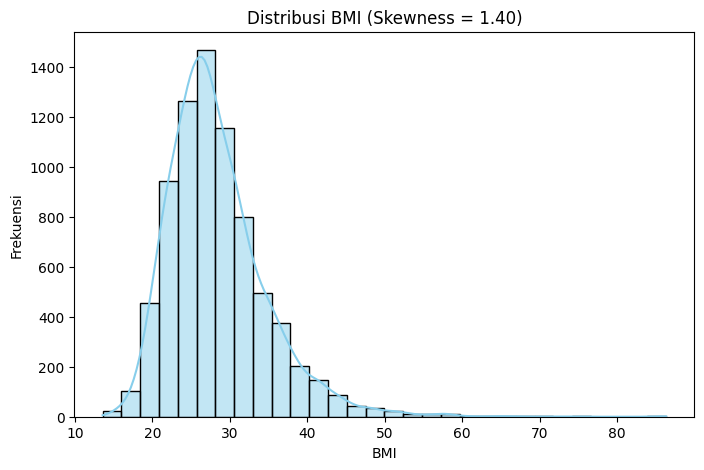

In [855]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Hitung skewness
bmi_skew = skew(x_train['BMI'].dropna())

# Visualisasi distribusi dengan histogram dan KDE
plt.figure(figsize=(8,5))
sns.histplot(x_train['BMI'], kde=True, bins=30, color='skyblue')

# Tambahkan judul dengan nilai skewness
plt.title(f'Distribusi BMI (Skewness = {bmi_skew:.2f})')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.show()


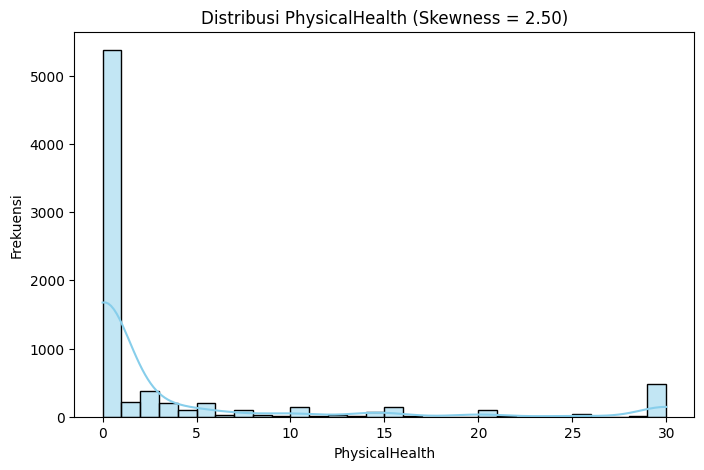

In [856]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Hitung skewness
bmi_skew = skew(x_train['PhysicalHealth'].dropna())

# Visualisasi distribusi dengan histogram dan KDE
plt.figure(figsize=(8,5))
sns.histplot(x_train['PhysicalHealth'], kde=True, bins=30, color='skyblue')

# Tambahkan judul dengan nilai skewness
plt.title(f'Distribusi PhysicalHealth (Skewness = {bmi_skew:.2f})')
plt.xlabel('PhysicalHealth')
plt.ylabel('Frekuensi')
plt.show()


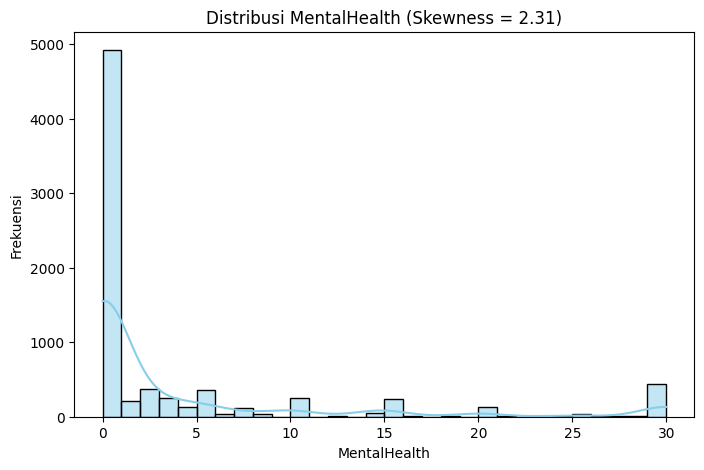

In [857]:
	
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Hitung skewness
bmi_skew = skew(x_train['MentalHealth'].dropna())

# Visualisasi distribusi dengan histogram dan KDE
plt.figure(figsize=(8,5))
sns.histplot(x_train['MentalHealth'], kde=True, bins=30, color='skyblue')

# Tambahkan judul dengan nilai skewness
plt.title(f'Distribusi MentalHealth (Skewness = {bmi_skew:.2f})')
plt.xlabel('MentalHealth')
plt.ylabel('Frekuensi')
plt.show()


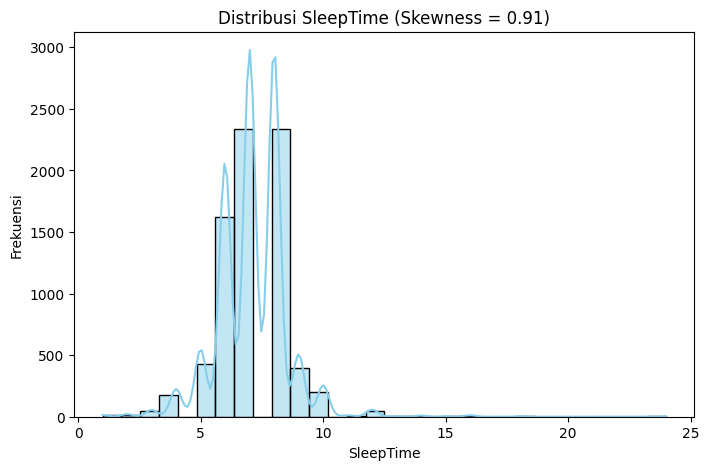

In [858]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Hitung skewness kolom BMI
bmi_skew = skew(x_train['SleepTime'].dropna())

# Visualisasi distribusi BMI dengan histogram dan KDE
plt.figure(figsize=(8,5))
sns.histplot(x_train['SleepTime'], kde=True, bins=30, color='skyblue')

# Tambahkan judul dengan nilai skewness
plt.title(f'Distribusi SleepTime (Skewness = {bmi_skew:.2f})')
plt.xlabel('SleepTime')
plt.ylabel('Frekuensi')
plt.show()


In [859]:
#check distribution form skewness
num_cols = list(x_train.select_dtypes(exclude='object').columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(x_train[col].skew(),1), np.where(
    (round(x_train[col].skew(),1) <= 0.5) & (round(x_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness

,nama kolom,nilai skewness,distribution
0,BMI,1.4,skewed
1,PhysicalHealth,2.5,skewed
2,MentalHealth,2.3,skewed
3,SleepTime,0.9,skewed


Terjadi skew yang besar pada kolom Physical dan Mental Health. Kemudian kolom BMI. Sedangkan SleepTime masih cenderung normal. Terjadinya skew tinggi ini karena banyak outlier pada dataset.

In [860]:
# Ambil semua kolom numerik
numerik_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Buat DataFrame untuk menyimpan hasil
outlier_summary = []

# Loop setiap kolom numerik
for col in numerik_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    # Hitung jumlah dan persentase outlier
    jumlah_outlier = df[(df[col] < batas_bawah) | (df[col] > batas_atas)].shape[0]
    persentase_outlier = (jumlah_outlier / len(df)) * 100

    # Simpan ke list
    outlier_summary.append({
        'Kolom': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Batas Bawah': batas_bawah,
        'Batas Atas': batas_atas,
        'Jumlah Outlier': jumlah_outlier,
        'Persentase Outlier (%)': round(persentase_outlier, 2)
    })

# Ubah ke DataFrame
outlier_df = pd.DataFrame(outlier_summary)

# Tampilkan hasil
outlier_df


,Kolom,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
0,BMI,24.03,31.42,7.39,12.945,42.505,10396,3.25
1,PhysicalHealth,0.00,2.00,2.00,-3.000,5.000,47146,14.74
2,MentalHealth,0.00,3.00,3.00,-4.500,7.500,51576,16.13
3,SleepTime,6.00,8.00,2.00,3.000,11.000,4543,1.42


In [861]:
x_train[num_list].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,7652.0,28.332980,6.372212,13.56,24.13,27.34,31.32,86.33
PhysicalHealth,7652.0,3.534631,8.114410,0.00,0.00,0.00,2.00,30.00
MentalHealth,7652.0,3.957789,8.045513,0.00,0.00,0.00,3.00,30.00
SleepTime,7652.0,7.119315,1.433493,1.00,6.00,7.00,8.00,24.00


BMI < 16 = Kurus berat (severe thinness). Jika BMI 13 ini sangat tidak lumrah, secara medis bisa terjadi, tapi berbahaya dan butuh penanganan serius.
BMI ≥ 40 diindikasikan sebagai obesitas kelas III. Jika BMMI 86 ini bisa saja terjadi, namun tidak lumrah.

SleepTime ini diidentifikasi sebagai per jam. Terdapat potensi seseorang hanya tidur satu jam sehari atau 24 jam sehari. Namun tidak normal/tidak lumrah

Diperlukan handling pada semua kolom numerik kecuali SleepTime karena presentasenya sangat kecil dan kemungkinan pada minimumnya jauh lebih masuk akal dibanding BMI.

**Handling outlier kolom BMI**

- Saya menggunakan Winsorize karena outlier Tidak Ekstrem, Tapi Cukup Mengganggu dan menjaga distribusi dan jumlah data.

In [862]:
import numpy as np
from scipy.stats.mstats import winsorize

bmi_upper_limit = 42.505
# Buat array BMI
bmi_array = x_train['BMI'].values

# Hitung proporsi yang ingin di-winsorize dari kanan
max_val = bmi_array.max()
prop_right = np.sum(bmi_array > bmi_upper_limit) / len(bmi_array)

# Terapkan winsorization hanya di sisi kanan
x_train['BMI'] = winsorize(bmi_array, limits=(0, prop_right))


**Handling outlier kolom PhysicalHealth dan MentalHealth**

- Saya menggunakan transformasi data skewed karena Transformasi log bisa membantu konvergensi lebih cepat dan prediksi lebih akurat, terutama pada model yang sensitif terhadap skala dan distribusi (regresi linear, KNN, neural nets).

In [863]:
import numpy as np

# Kolom yang akan ditransformasikan
cols = ['PhysicalHealth', 'MentalHealth']

# Terapkan log1p: log(1 + x), aman untuk nilai 0
x_train[cols] = x_train[cols].applymap(np.log1p)

C:\Users\anand\AppData\Local\Temp\ipykernel_3788\2680125474.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x_train[cols] = x_train[cols].applymap(np.log1p)


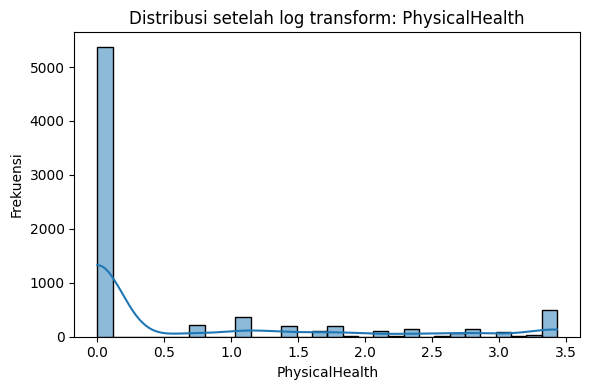

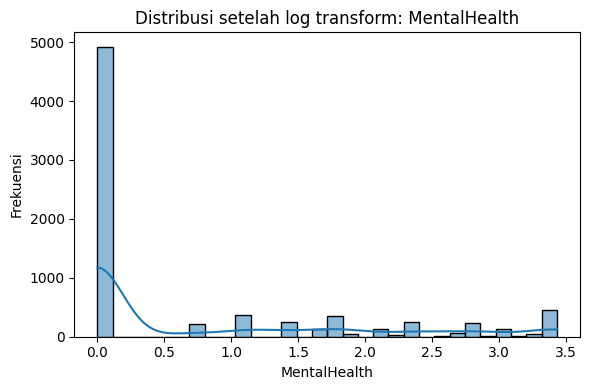

In [864]:
# Lihat deskripsi statistik baru
x_train[cols].describe().T

# Atau histogram distribusi
import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(x_train[col], bins=30, kde=True)
    plt.title(f'Distribusi setelah log transform: {col}')
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


After handling outlier

In [865]:
x_train[num_list].skew()

BMI               0.629474
PhysicalHealth    1.533980
MentalHealth      1.194382
SleepTime         0.908873
dtype: float64

BMI dan SleepTime saat ini memiliki skewness < 1, artinya distribusi mereka sudah cukup simetris.

PhysicalHealth dan MentalHealth masih sedikit skewed (> 1), tapi ini sudah jauh lebih baik dibandingkan sebelum transformasi.

## f. Feature Selection

Digunakan kendall karena targetnya kategorik namun inputannya terdapat kolom categorik dan numerik.

In [866]:
from scipy.stats import kendalltau
import pandas as pd

kendall_cols = []
kendall_scores = []
kendall_interpretasi = []

for col in x_train:
    coef, _ = kendalltau(x_train[col], y_train)
    kendall_cols.append(col)
    kendall_scores.append(coef)
    if coef == 0:
        kendall_interpretasi.append('tidak ada korelasi')
    else:
        kendall_interpretasi.append('ada korelasi')

kendall_df = pd.DataFrame({
    'nama kolom': kendall_cols,
    'skor korelasi': kendall_scores,
    'hasil': kendall_interpretasi
})

kendall_df


,nama kolom,skor korelasi,hasil
0,BMI,0.040462,ada korelasi
1,Smoking,0.098994,ada korelasi
2,AlcoholDrinking,-0.013858,ada korelasi
3,Stroke,0.181736,ada korelasi
4,PhysicalHealth,0.134285,ada korelasi
5,MentalHealth,-0.011031,ada korelasi
6,DiffWalking,0.209074,ada korelasi
7,Sex,0.052986,ada korelasi
8,AgeCategory,0.206945,ada korelasi
9,Race,0.035395,ada korelasi


Terlihat bahwa semua kolom memiliki korelasi dengan target. karena tidak ada yang benar-benar 0

In [867]:
x_train

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,SleepCategory
266905,29.41,No,No,Yes,0.000000,0.000000,No,Male,75-79,Hispanic,Yes,Yes,Good,8.0,No,No,No,Normal (6-9h)
134065,23.57,Yes,No,No,0.000000,1.791759,No,Female,55-59,White,No,Yes,Very good,8.0,Yes,No,Yes,Normal (6-9h)
79508,36.02,Yes,No,No,0.000000,1.791759,No,Female,60-64,White,No,No,Very good,7.0,Yes,No,No,Normal (6-9h)
39445,31.89,No,No,No,0.000000,1.098612,No,Female,70-74,White,No,No,Good,7.0,No,No,No,Normal (6-9h)
160219,21.70,No,No,No,0.000000,0.000000,No,Male,70-74,Black,No,Yes,Very good,8.0,No,No,No,Normal (6-9h)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187371,21.58,Yes,Yes,No,0.000000,0.000000,No,Female,55-59,White,No,Yes,Good,5.0,No,No,No,Short (<6h)
63324,23.89,No,No,No,3.433987,2.397895,Yes,Female,50-54,Asian,No,No,Good,5.0,No,No,No,Short (<6h)
125305,25.11,No,No,Yes,0.000000,0.000000,No,Male,70-74,White,No,Yes,Very good,8.0,No,No,Yes,Normal (6-9h)
141113,18.83,No,No,No,1.098612,2.564949,No,Male,18-24,Other,No,Yes,Very good,8.0,Yes,No,No,Normal (6-9h)


In [868]:
cat_cols = [
 'Smoking',
 'AlcoholDrinking',
 'Stroke',
 'DiffWalking',
 'Sex',
 'AgeCategory',
 'Race',
 'Diabetic',
 'PhysicalActivity',
 'GenHealth',
 'Asthma',
 'KidneyDisease',
 'SkinCancer']
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

## e. Column Transformer

In [869]:
# Membuat column Transformer

transformer = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])


# Modeling I

## Model Definisition

In [870]:

#Making pipeline for LogReg
pipe_SVM = Pipeline([
('transformer', transformer),
('classifier', SVC(random_state=42))
])

#Making pipeline for Decision Tree
pipe_KNN = Pipeline([
('transformer', transformer),
('classifier', KNeighborsClassifier())
])

#Making pipeline for Random Forest
pipe_DT = Pipeline([
('transformer', transformer),
('classifier', DecisionTreeClassifier(random_state=42))
])

#Making pipeline for XGBoost
pipe_RF = Pipeline([
('transformer', transformer),
('classifier',RandomForestClassifier(random_state=42))
])

#Making pipeline for XGBoost
pipe_xgb = Pipeline([
('transformer', transformer),
('classifier', XGBClassifier(random_state=42))
])

## SVM

In [871]:
pipe_SVM

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Smoking', 'AlcoholDrinking',
                                                   'Stroke', 'DiffWalking',
                                                   'Sex', 'AgeCategory', 'Race',
                                                   'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'Asthma',
                                                   'KidneyDisease',
                                                   'SkinCancer']),
                                                 ('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'SleepTime'])])),
                ('classifier', SVC(random_state=42))])

In [872]:
pipe_SVM.fit(x_train, y_train)
print('Training Score: ',round(pipe_SVM.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_SVM.score(x_test, y_test),4))

Training Score:  0.9107
Testing Score:  0.9007


Karena selisih diantara train dan testnya sangat kecil yaitu 0.0016 yang bisa dibilang bahwa model ini goodfit.

In [873]:
y_SVM_pred = pipe_SVM.predict(x_test)
y_SVM_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [874]:
target = ['non HeartDisease', 'HeartDisease']
print(classification_report(y_test, y_SVM_pred, target_names = target))

                  precision    recall  f1-score   support

non HeartDisease       0.90      1.00      0.95      1724
    HeartDisease       0.00      0.00      0.00       190

        accuracy                           0.90      1914
       macro avg       0.45      0.50      0.47      1914
    weighted avg       0.81      0.90      0.85      1914



c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [875]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_SVM, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.727
Nilai Standard Deviasi Cross Validation: 0.020


## KNN

In [876]:
pipe_KNN

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Smoking', 'AlcoholDrinking',
                                                   'Stroke', 'DiffWalking',
                                                   'Sex', 'AgeCategory', 'Race',
                                                   'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'Asthma',
                                                   'KidneyDisease',
                                                   'SkinCancer']),
                                                 ('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'SleepTime'])])),
                ('classifier', KNeighborsClassifier())])

In [877]:
pipe_KNN.fit(x_train, y_train)
print('Training Score: ',round(pipe_KNN.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_KNN.score(x_test, y_test),4))

Training Score:  0.9177
Testing Score:  0.8976


Karena selisih diantara train dan testnya sangat kecil yang mengindikasikan bahwa model ini goodfit. Selisihnya  0.94%

In [878]:
y_KNN_pred = pipe_KNN.predict(x_test)
y_KNN_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [879]:
target = ['non HeartDisease', 'HeartDisease']
print(classification_report(y_test, y_KNN_pred, target_names = target))

                  precision    recall  f1-score   support

non HeartDisease       0.91      0.99      0.95      1724
    HeartDisease       0.42      0.08      0.13       190

        accuracy                           0.90      1914
       macro avg       0.66      0.53      0.54      1914
    weighted avg       0.86      0.90      0.86      1914



In [880]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_KNN,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.09756098 0.1125     0.14201183 0.07272727 0.14201183]
F1 Score - Mean - Cross Validation :  0.11336238339521643
F1 Score - Std - Cross Validation  :  0.02662037749036516
F1 Score - Range of Test-Set       :  0.08674200590485126 - 0.1399827608855816


In [881]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_KNN, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.679
Nilai Standard Deviasi Cross Validation: 0.021


## Decision Tree

In [882]:
pipe_DT

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Smoking', 'AlcoholDrinking',
                                                   'Stroke', 'DiffWalking',
                                                   'Sex', 'AgeCategory', 'Race',
                                                   'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'Asthma',
                                                   'KidneyDisease',
                                                   'SkinCancer']),
                                                 ('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'SleepTime'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [883]:
pipe_DT.fit(x_train, y_train)
print('Training Score: ',round(pipe_DT.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_DT.score(x_test, y_test),4))

Training Score:  0.9999
Testing Score:  0.8527


Model ini mangalami overfitting. Skor training yang sangat tinggi tetapi skor testing yang signifikan lebih rendah adalah ciri khas dari overfitting

In [884]:
y_DT_pred = pipe_DT.predict(x_test)
y_DT_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [885]:
target = ['non HeartDisease', 'HeartDisease']
print(classification_report(y_test, y_DT_pred, target_names = target))

                  precision    recall  f1-score   support

non HeartDisease       0.92      0.92      0.92      1724
    HeartDisease       0.27      0.27      0.27       190

        accuracy                           0.85      1914
       macro avg       0.59      0.60      0.59      1914
    weighted avg       0.85      0.85      0.85      1914



In [886]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_DT,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.25       0.20069204 0.24113475 0.22435897 0.25242718]
F1 Score - Mean - Cross Validation :  0.23372259042410698
F1 Score - Std - Cross Validation  :  0.019227326923907603
F1 Score - Range of Test-Set       :  0.21449526350019937 - 0.2529499173480146


In [887]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_DT, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.581
Nilai Standard Deviasi Cross Validation: 0.011


## Random Forest

In [888]:
pipe_RF.fit(x_train, y_train)
print('Training Score: ',round(pipe_RF.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_RF.score(x_test, y_test),4))

Training Score:  0.9997
Testing Score:  0.8908


Selisih tidak terlalu besar sekitar 9.4%. Model ini cenderung tidak terlalu besar

In [889]:
y_RF_pred = pipe_RF.predict(x_test)
y_RF_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [890]:
target = ['non HeartDisease', 'HeartDisease']
print(classification_report(y_test, y_RF_pred, target_names = target))

                  precision    recall  f1-score   support

non HeartDisease       0.90      0.98      0.94      1724
    HeartDisease       0.26      0.05      0.09       190

        accuracy                           0.89      1914
       macro avg       0.58      0.52      0.51      1914
    weighted avg       0.84      0.89      0.86      1914



In [891]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_RF,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.13836478 0.10191083 0.07792208 0.08974359 0.10062893]
F1 Score - Mean - Cross Validation :  0.10171404127659385
F1 Score - Std - Cross Validation  :  0.020267422429359055
F1 Score - Range of Test-Set       :  0.0814466188472348 - 0.1219814637059529


In [892]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_RF, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.782
Nilai Standard Deviasi Cross Validation: 0.021


## XGBoost

In [893]:
pipe_xgb.fit(x_train, y_train)
print('Training Score: ',round(pipe_xgb.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_xgb.score(x_test, y_test),4))

Training Score:  0.9693
Testing Score:  0.8929


Model ini cenderung goodfit karena selisihnya 6%

In [894]:
y_xgb_pred = pipe_xgb.predict(x_test)
y_xgb_pred

array([0, 0, 0, ..., 0, 0, 0])

In [895]:
target = ['non HeartDisease', 'HeartDisease']
print(classification_report(y_test, y_xgb_pred, target_names = target))

                  precision    recall  f1-score   support

non HeartDisease       0.91      0.98      0.94      1724
    HeartDisease       0.36      0.11      0.16       190

        accuracy                           0.89      1914
       macro avg       0.64      0.54      0.55      1914
    weighted avg       0.85      0.89      0.87      1914



In [896]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_xgb,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.11695906 0.31578947 0.17582418 0.15544041 0.1978022 ]
F1 Score - Mean - Cross Validation :  0.1923630652291683
F1 Score - Std - Cross Validation  :  0.06721047956722777
F1 Score - Range of Test-Set       :  0.12515258566194054 - 0.25957354479639605


In [897]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_xgb, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.781
Nilai Standard Deviasi Cross Validation: 0.024


# Model Comparison

In [898]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost' : pipe_xgb
}

metrics = {
    'Accuracy' : accuracy_score,
    'F1-Score' : f1_score,
    'Recall' : recall_score,
}

df_model = pd.DataFrame(columns = models.keys(), index=['Accuracy', 'F1-Score', 'Recall'])

for metric in metrics.keys():
  for model in models.keys():
    df_model.loc[metric, model] = metrics[metric](y_test, models[model].predict(x_test))

In [899]:
df_model

,SVM,KNN,Decision Tree,Random Forest,XGBoost
Accuracy,0.900731,0.897597,0.852665,0.890805,0.892894
F1-Score,0.0,0.132743,0.26943,0.087336,0.163265
Recall,0.0,0.078947,0.273684,0.052632,0.105263


- Accuracy digunakan untuk mengukur banyak prediksi yang benar. Semakin besar akurasi menunjukkan model makin bagus.

Pada data ini semua model menunjukkan hasil accuracy yang tinggi karena mendekati angka 1.


- gambaran seimbang antara seberapa akurat model saat prediksi positif, dan seberapa banyak yang berhasil ditangkap dari semua yang positif.

Pada data ini semua model menunjukkan hasil F1-Score yang tidak bagus.

-**Recall** 
Mengukur seberapa banyak kasus positif yang berhasil ditemukan model.

Pada kasus ini untuk menentukan best modelnya saya melihat dari recall karena Semakin tinggi recall, semakin sedikit False Negative.

Berdasarkan dataset dan model yang sudah saya kerjakan saya menentukan Decision Tree sebagai model terbaik karena diantara yang lain dia yang paling besar


In [900]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost' : pipe_xgb
}

metrics = {
    'Mean' : cross_val_score(models[model], x_train, y_train, cv = 5, scoring='f1').mean(),
    'Std' : cross_val_score(models[model], x_train, y_train, cv = 5, scoring='f1').std()
}

df_cross_val = pd.DataFrame(columns = models.keys(), index = ['Mean', 'Std'])

for i in metrics.keys():
  for j in models.keys():
    df_cross_val.loc[i, j] = metrics[i]

In [901]:
df_cross_val

,SVM,KNN,Decision Tree,Random Forest,XGBoost
Mean,0.192363,0.192363,0.192363,0.192363,0.192363
Std,0.06721,0.06721,0.06721,0.06721,0.06721


In [902]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost'       : pipe_xgb
}

# Buat DataFrame kosong untuk menyimpan hasil ROC-AUC
df_roc_auc = pd.DataFrame(columns=models.keys(), index=['Mean', 'Std'])

# Hitung ROC-AUC cross validation untuk setiap model
for model_name, model_pipeline in models.items():
    roc_auc_scores = cross_val_score(model_pipeline, x_train, y_train, cv=5, scoring='roc_auc')
    df_roc_auc.loc['Mean', model_name] = roc_auc_scores.mean()
    df_roc_auc.loc['Std', model_name] = roc_auc_scores.std()

# Konversi nilai ke float dan bulatkan 3 desimal
df_roc_auc = df_roc_auc.astype(float).round(3)

# Tampilkan hasil
print(df_roc_auc)

        SVM    KNN  Decision Tree  Random Forest  XGBoost
Mean  0.727  0.679          0.581          0.782    0.781
Std   0.020  0.021          0.011          0.021    0.024


# Modeling II

In [903]:
##Parameter Tuning
param_grid_DT = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

grid_DT = GridSearchCV(
    estimator=pipe_DT,
    param_grid=param_grid_DT,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_DT.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Smoking',
                                                                          'AlcoholDrinking',
                                                                          'Stroke',
                                                                          'DiffWalking',
                                                                          'Sex',
                                                                          'AgeCategory',
                                                                          'Race',
                                                                          'Diabetic',
                                                                          'PhysicalActivity',
                                                                          'GenHealth',
                                                                          'Asthma',
                                                                          'KidneyDisease',
                                                                          'SkinCancer']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['BMI',
                                                                          'PhysicalHealth',
                                                                          'MentalHealth',
                                                                          'SleepTime'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 10, None],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [904]:
print("Best parameters:", grid_DT.best_params_)
print("Best score (CV accuracy):", grid_DT.best_score_)

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Best score (CV accuracy): 0.9093047817864355


## Model Evaluation After Tunning

In [905]:
models = {
    'Random Forest' : grid_DT
}

metrics = {
    'Accuracy' : accuracy_score,
    'F1-Score' : f1_score,
}

model_tuning = pd.DataFrame(columns = models.keys(), index=['Accuracy', 'F1-Score'])

for metric in metrics.keys():
  for model in models.keys():
    model_tuning.loc[metric, model] = metrics[metric](y_test, models[model].predict(x_test))

In [906]:
grid_DT.fit(x_train, y_train)
print('Training Score: ',round(grid_DT.score(x_train, y_train),4))
print('Testing Score: ', round(grid_DT.score(x_test, y_test),4))

Training Score:  0.9104
Testing Score:  0.9007


Setelah dilakukan tunning model menjadi goodfit karena selisih antara train dan testnya kecil

In [907]:
print(classification_report(y_test, grid_DT.predict(x_test)))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1724
           1       0.00      0.00      0.00       190

    accuracy                           0.90      1914
   macro avg       0.45      0.50      0.47      1914
weighted avg       0.81      0.90      0.85      1914



c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Hasil classification report menunjukkan bahwa model decision tree tidak berhasil mengklasifikasikan sama sekali kelas minoritas (class 1), dengan nilai precision, recall, dan f1-score sebesar 0.00. Hal ini terjadi karena dataset tidak seimbang, di mana jumlah class 1 (190) jauh lebih sedikit dibandingkan class 0 (1724).

Pada kondisi seperti ini, decision tree cenderung bias terhadap kelas mayoritas, karena algoritma ini memecah data berdasarkan impurity (seperti Gini atau entropy). Ketika class minoritas terlalu kecil, model menganggapnya tidak signifikan dalam proses pemisahan, sehingga memilih untuk mengklasifikasikan seluruh data sebagai class 0 untuk memaksimalkan akurasi.

Meskipun akurasi terlihat tinggi (90%), hal ini menyesatkan karena model gagal sepenuhnya mengenali class 1, yang dapat berisiko besar jika class 1 merupakan kategori penting (misalnya, kasus fraud atau penyakit). Oleh karena itu, perlu dipertimbangkan penanganan imbalance, seperti resampling data atau memberi bobot lebih besar pada class minoritas.

# Kesimpulan

- **Kesimpulan EDA (Exploratory Data Analysis)**

Dataset memiliki 319.795 baris dan 18 kolom, mayoritas bertipe object.

Target klasifikasi adalah kolom HeartDisease.

Proporsi target tidak seimbang, namun tetap memungkinkan untuk supervised learning.

Visualisasi menunjukkan korelasi antara beberapa fitur gaya hidup dan kondisi medis dengan HeartDisease, misalnya:

Penderita diabetes dan stroke cenderung memiliki risiko lebih tinggi.

Faktor usia dan jenis kelamin juga cukup berpengaruh

- **Kesimpulan Modeling 1 (Baseline Modeling)**

Model

- **Kesimpulan Modeling 2 (Model Optimization)**

- **Sebelum Tuning:**
    Model memiliki akurasi 85%, namun masih dapat mengenali sebagian kasus HeartDisease dengan:

    Precision: 0.27

    Recall: 0.27

    F1-score: 0.27

    Keseimbangan performa antar kelas masih terjaga meskipun belum optimal, terlihat dari macro avg F1-score sebesar 0.59.

- **Setelah Tuning:**
    Akurasi meningkat menjadi 90%, namun kinerja terhadap kelas HeartDisease menurun drastis:

    Precision, Recall, dan F1-score untuk HeartDisease menjadi 0.00

    Model menjadi sangat bias terhadap kelas mayoritas (non-HeartDisease), dan tidak mampu mendeteksi satu pun kasus HeartDisease.

    Macro avg F1-score menurun menjadi 0.47, menunjukkan penurunan kemampuan generalisasi antar kelas.

- **Kesimpulan:**
    Tuning berhasil meningkatkan akurasi keseluruhan, namun mengorbankan performa terhadap kelas minoritas yang penting (HeartDisease).

    Hal ini menunjukkan bahwa akurasi bukan metrik yang cukup untuk mengevaluasi model pada data tidak seimbang.

    Model setelah tuning tidak dapat digunakan secara andal untuk mendeteksi HeartDisease, meskipun akurasinya tampak tinggi.

- **Rekomendasi Lanjutan:**
    Fokus tuning ke metrik seperti F1-score khusus kelas HeartDisease atau macro average.

    Terapkan teknik penyeimbangan data seperti:

    SMOTE atau oversampling

    Class weight balancing

    Evaluasi dengan confusion matrix dan visualisasi ROC/PR curve untuk pemahaman lebih lanjut.

# Model Saving

In [915]:
#Simpan model
joblib.dump(grid_DT, "best_model.pkl")

['best_model.pkl']